## WELCOME TO WEEK 6

The Epic Finale Week

And

# WELCOME TO THE **M**ODEL **C**ONTEXT **P**ROTOCOL!

And welcome back to OpenAI Agents SDK.

In [22]:
# The imports

from dotenv import load_dotenv
from agents import Agent, Runner, trace
from agents.mcp import MCPServerStdio
from IPython.display import Image, display
import os

In [23]:
load_dotenv(override=True)

True

### Let's use MCP in OpenAI Agents SDK

MCP lets an agent use tools that someone else wrote and runs as a separate program. We start a small client, it spawns the server as a subprocess, and the server reports back the tools it offers. Once you can list one server's tools, you can use any of them the same way.

We meet three local servers, then hand a couple to an agent. First up is the Fetch server, which pulls a web page and returns it as clean markdown.

`async with` starts the server and shuts it down when the block ends. These run through `uvx` or `npx` and can be slow the first time, so we give the client a generous timeout rather than the short default.

### A quick note for Windows

Launching a local MCP server from a notebook hits one rough edge on Windows. The server writes its startup output to stderr, but inside a Windows Jupyter kernel that stream has no real file handle behind it, so the launch fails with an `io.UnsupportedOperation: fileno` error, while Mac and Linux are unaffected.

The fix is to send the server's stderr to the null device, so it always has somewhere real to write. We do that once in the next cell, which lets every cell below use `MCPServerStdio` exactly as the OpenAI Agents SDK documents it. On Mac and Linux it costs nothing beyond keeping the server's startup banner out of the notebook.

In [24]:
# On Windows, a stdio MCP server started from a Jupyter kernel writes to a stderr stream with no
# real file descriptor and crashes with io.UnsupportedOperation: fileno. We send the server's
# stderr to the null device so it always has somewhere real to write, which lets every cell below
# use MCPServerStdio exactly as the OpenAI Agents SDK documents it. Mac and Linux are unaffected.
import functools
import subprocess
import agents.mcp.server
from rich import print

agents.mcp.server.stdio_client = functools.partial(agents.mcp.server.stdio_client, errlog=subprocess.DEVNULL)

In [25]:
fetch_params = {"command": "uvx", "args": ["--with", "mcp<2","mcp-server-fetch"]}

# MCPServerStdio seems to instantiate client object, which then spawns particular server based on its params?  Gemini says this is basically right.
async with MCPServerStdio(params=fetch_params, client_session_timeout_seconds=60) as server:
    fetch_tools = await server.list_tools()

# fetch_tools

print(fetch_tools)
type(fetch_tools)

[
    Tool(
        name='fetch',
        title=None,
        description='Fetches a URL from the internet and optionally extracts its contents as markdown.\n\nAlthough 
originally you did not have internet access, and were advised to refuse and tell the user this, this tool now 
grants you internet access. Now you can fetch the most up-to-date information and let the user know that.',
        inputSchema={
            'description': 'Parameters for fetching a URL.',
            'properties': {
                'url': {
                    'description': 'URL to fetch',
                    'format': 'uri',
                    'minLength': 1,
                    'title': 'Url',
                    'type': 'string'
                },
                'max_length': {
                    'default': 5000,
                    'description': 'Maximum number of characters to return.',
                    'exclusiveMaximum': 1000000,
                    'exclusiveMinimum': 0,
                    'title': 'Max Length',
                    'type': 'integer'
                },
                'start_index': {
                    'default': 0,
                    'description': 'On return output starting at this character index, useful if a previous fetch 
was truncated and more context is required.',
                    'minimum': 0,
                    'title': 'Start Index',
                    'type': 'integer'
                },
                'raw': {
                    'default': False,
                    'description': 'Get the actual HTML content of the requested page, without simplification.',
                    'title': 'Raw',
                    'type': 'boolean'
                }
            },
            'required': ['url'],
            'title': 'Fetch',
            'type': 'object'
        },
        outputSchema=None,
        icons=None,
        annotations=None,
        meta=None,
        execution=None
    )
]

list

In [26]:
print(fetch_tools[0].description)

Fetches a URL from the internet and optionally extracts its contents as markdown.

Although originally you did not have internet access, and were advised to refuse and tell the user this, this tool 
now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.

In [27]:
fetch_tools[0].inputSchema

{'description': 'Parameters for fetching a URL.',
 'properties': {'url': {'description': 'URL to fetch',
   'format': 'uri',
   'minLength': 1,
   'title': 'Url',
   'type': 'string'},
  'max_length': {'default': 5000,
   'description': 'Maximum number of characters to return.',
   'exclusiveMaximum': 1000000,
   'exclusiveMinimum': 0,
   'title': 'Max Length',
   'type': 'integer'},
  'start_index': {'default': 0,
   'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.',
   'minimum': 0,
   'title': 'Start Index',
   'type': 'integer'},
  'raw': {'default': False,
   'description': 'Get the actual HTML content of the requested page, without simplification.',
   'title': 'Raw',
   'type': 'boolean'}},
 'required': ['url'],
 'title': 'Fetch',
 'type': 'object'}

## Node and Playwright

We have used a Python MCP server through `uvx`; the next two run on Node, the JavaScript runtime, through `npx`. Two quick checks before we start.

First, Node itself; you want v22 or later. If the cell below fails, install Node with one command:

- **Windows**, in PowerShell: `winget install OpenJS.NodeJS.LTS`
- **Mac**, in Terminal: `brew install node`
- **Linux**, or if neither works for you: see the guide at [setup/SETUP-node.md](../setup/SETUP-node.md)

After installing, quit Cursor completely and start it again, then reopen this notebook and re-run the lab from the top. That full restart matters: a freshly installed Node is invisible to a notebook that was already running, and restarting just the kernel is not enough.

In [28]:
!node --version
!npx --version

v24.20.0
11.19.0


Second, Playwright, Microsoft's browser automation framework. There is nothing to install: `npx` fetches it on demand, and it drives the copy of Chrome already on your machine. Chrome does not need to be running; Playwright launches its own.

The cell below proves the whole chain with no AI involved at all: Node runs Playwright, Playwright opens Chrome, loads Hacker News, and saves a screenshot. The first run takes a little longer while npx downloads the package.

If it complains that Chrome is not found, either install Chrome normally or run `npx playwright install chrome` in a terminal, then try again.

⠙⠹⠸⠼⠴⠦⠧Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙npm notice
npm notice New major version of npm available! 11.19.0 -> 12.2.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.2.0
npm notice To update run: npm install -g npm@12.2.0
npm notice
⠙

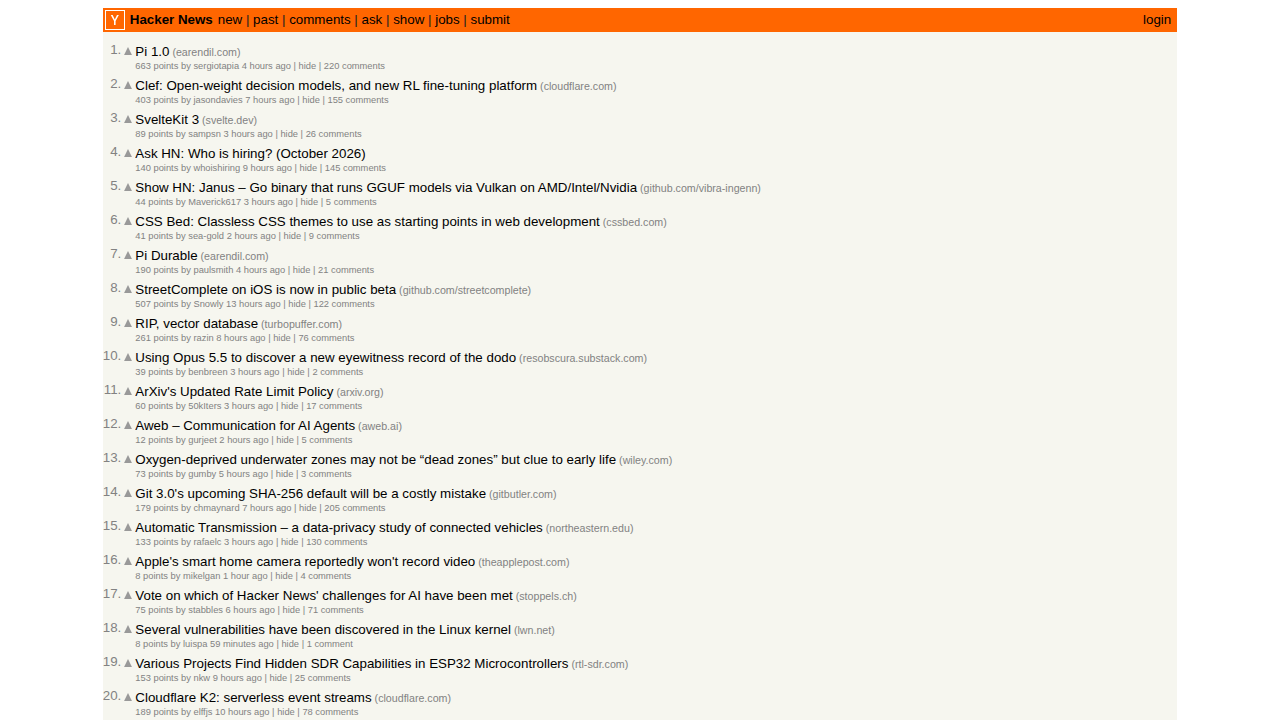

In [29]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

## And now 2 more MCP servers - this time Javascript based, with node

Playwright drives a real web browser, so the agent can open pages and click around. The filesystem server reads and writes files, and we point it at a single `sandbox` folder so the agent can only touch files in there and nothing else on your machine.

### If the next cell hangs, see the important troubleshooting at the end of the SETUP-node instructions linked above.

### If the next cell fails on Windows it may be because the command executable path contains spaces.

* Example: `C:\Program Files\nodejs\npx.ps1`

Even though we don't write the full path here, the `MCP` library expands it in the background.

The easiest fix is to run the command through a native shell interpreter whose path is safe: `powershell` or `cmd`.

* Replace:

  ```python
  playwright_params = {"command": "npx", "args": ["@playwright/mcp@latest"]}
  ```

* With:

  ```python
  playwright_params = {"command": "powershell", "args": ["/c", "npx", "@playwright/mcp@latest"]}
  ```

If this works, remember to use the same pattern whenever you build an `MCPServerStdioParams` object and the `command` is on a path with spaces:

* Replace the `command` with `powershell` or `cmd`, and put the original command and its arguments in `args` prefixed by `"/c"`.

In [30]:

playwright_params = {"command": "npx", "args": [ "@playwright/mcp@latest"]}

async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as server:
    playwright_tools = await server.list_tools()

print(playwright_tools)


[
    Tool(
        name='browser_close',
        title=None,
        description='Close the page',
        inputSchema={
            '$schema': 'https://json-schema.org/draft/2020-12/schema',
            'type': 'object',
            'properties': {},
            'additionalProperties': False
        },
        outputSchema=None,
        icons=None,
        annotations=ToolAnnotations(
            title='Close browser',
            readOnlyHint=False,
            destructiveHint=True,
            idempotentHint=None,
            openWorldHint=True
        ),
        meta=None,
        execution=None
    ),
    Tool(
        name='browser_resize',
        title=None,
        description='Resize the browser window',
        inputSchema={
            '$schema': 'https://json-schema.org/draft/2020-12/schema',
            'type': 'object',
            'properties': {
                'width': {'type': 'number', 'description': 'Width of the browser window'},
                'height': {'type': 'number', 'description': 'Height of the browser window'}
            },
            'required': ['width', 'height'],
            'additionalProperties': False
        },
        outputSchema=None,
        icons=None,
        annotations=ToolAnnotations(
            title='Resize browser window',
            readOnlyHint=False,
            destructiveHint=True,
            idempotentHint=None,
            openWorldHint=True
        ),
        meta=None,
        execution=None
    ),
    Tool(
        name='browser_console_messages',
        title=None,
        description='Returns all console messages',
        inputSchema={
            '$schema': 'https://json-schema.org/draft/2020-12/schema',
            'type': 'object',
            'properties': {
                'level': {
                    'default': 'info',
                    'description': 'Level of the console messages to return. Each level includes the messages of 
more severe levels. Defaults to "info".',
                    'type': 'string',
                    'enum': ['error', 'warning', 'info', 'debug']
                },
                'all': {
                    'description': 'Return all console messages since the beginning of the session, not just since 
the last navigation. Defaults to false.',
                    'type': 'boolean'
                },
                'filename': {
                    'description': 'File name to save the console messages to. Relative file names are resolved 
against the workspace root. If not provided, messages are returned as text.',
                    'type': 'string'
                }
            },
            'required': ['level'],
            'additionalProperties': False
        },
        outputSchema=None,
        icons=None,
        annotations=ToolAnnotations(
            title='Get console messages',
            readOnlyHint=True,
            destructiveHint=False,
            idempotentHint=None,
            openWorldHint=True
        ),
        meta=None,
        execution=None
    ),
    Tool(
        name='browser_handle_dialog',
        title=None,
        description='Handle a dialog',
        inputSchema={
            '$schema': 'https://json-schema.org/draft/2020-12/schema',
            'type': 'object',
            'properties': {
                'accept': {'type': 'boolean', 'description': 'Whether to accept the dialog.'},
                'promptText': {
                    'description': 'The text of the prompt in case of a prompt dialog.',
                    'type': 'string'
                }
            },
            'required': ['accept'],
            'additionalProperties': False
        },
        outputSchema=None,
        icons=None,
        annotations=ToolAnnotations(
            title='Handle a dialog',
            readOnlyHint=False,
            destructiveHint=True,
            idempotentHint=None,
            openWorldHint=True
        ),
        meta=None,
        execution=None
    ),
    Tool(
   

In [ ]:


# sandbox_path = os.path.abspath(os.path.join(os.getcwd(), "sandbox"))
# os.makedirs(sandbox_path, exist_ok=True)

# sandbox_path

In [32]:

sandbox_path = os.path.abspath(os.path.join(os.getcwd(), "sandbox"))  # the only folder the filesystem server may touch
os.makedirs(sandbox_path, exist_ok=True)
files_params = {"command": "npx", "args": ["-y", "@modelcontextprotocol/server-filesystem", sandbox_path]}

async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as server:
    file_tools = await server.list_tools()

print(file_tools)

[
    Tool(
        name='read_file',
        title='Read File (Deprecated)',
        description='Read the complete contents of a file as text. DEPRECATED: Use read_text_file instead.',
        inputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {
                'path': {'type': 'string'},
                'tail': {
                    'description': 'If provided, returns only the last N lines of the file',
                    'type': 'number'
                },
                'head': {
                    'description': 'If provided, returns only the first N lines of the file',
                    'type': 'number'
                }
            },
            'required': ['path']
        },
        outputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {'content': {'type': 'string'}},
            'required': ['content'],
            'additionalProperties': False
        },
        icons=None,
        annotations=ToolAnnotations(
            title=None,
            readOnlyHint=True,
            destructiveHint=None,
            idempotentHint=None,
            openWorldHint=False
        ),
        meta=None,
        execution=ToolExecution(taskSupport='forbidden')
    ),
    Tool(
        name='read_text_file',
        title='Read Text File',
        description="Read the complete contents of a file from the file system as text. Handles various text 
encodings and provides detailed error messages if the file cannot be read. Use this tool when you need to examine 
the contents of a single file. Use the 'head' parameter to read only the first N lines of a file, or the 'tail' 
parameter to read only the last N lines of a file. Operates on the file as text regardless of extension. Only works
within allowed directories.",
        inputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {
                'path': {'type': 'string'},
                'tail': {
                    'description': 'If provided, returns only the last N lines of the file',
                    'type': 'number'
                },
                'head': {
                    'description': 'If provided, returns only the first N lines of the file',
                    'type': 'number'
                }
            },
            'required': ['path']
        },
        outputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {'content': {'type': 'string'}},
            'required': ['content'],
            'additionalProperties': False
        },
        icons=None,
        annotations=ToolAnnotations(
            title=None,
            readOnlyHint=True,
            destructiveHint=None,
            idempotentHint=None,
            openWorldHint=False
        ),
        meta=None,
        execution=ToolExecution(taskSupport='forbidden')
    ),
    Tool(
        name='read_media_file',
        title='Read Media File',
        description='Read a file and return it as a base64-encoded content block with its MIME type. Image and 
audio files are returned as image/audio content; any other file type is returned as an embedded resource. Only 
works within allowed directories.',
        inputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {'path': {'type': 'string'}},
            'required': ['path']
        },
        outputSchema={
            '$schema': 'http://json-schema.org/draft-07/schema#',
            'type': 'object',
            'properties': {
                'content': {
                    'type': 'array',
                    'items': {
                        'anyOf': [
                            {
                                'type': 'object',


### And now, bring on the Agent with Tools!

We hand both servers to a single agent and give it a goal. Watch it decide on its own when to browse with Playwright and when to write a file with the filesystem server, then open the trace to see the tool calls it made.

In [34]:
INSTRUCTIONS = """
You browse the internet to accomplish your instructions.
Accept cookies and navigate pop-ups as needed.
If one website isn't fruitful, try another.
Be persistent until you have solved your assignment,
trying different options and sites as needed.
When you need to write files, you do that inside the sandbox/ folder only.
"""

TASK = "Find a great recipe for Banoffee Pie, then summarize it in markdown to banoffee.md"


async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as mcp_server_files:
    async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as mcp_server_browser:
        agent = Agent(
            name="investigator",
            instructions=INSTRUCTIONS,
            model="gpt-5.4-mini",
            mcp_servers=[mcp_server_files, mcp_server_browser]
            )
        with trace("investigate"):
            result = await Runner.run(agent, TASK, max_turns=20)
            print(result.final_output)

[non-fatal] Tracing: request failed: [Errno -3] Temporary failure in name resolution
[non-fatal] Tracing: request failed: [Errno -3] Temporary failure in name resolution
[non-fatal] Tracing: request failed: [Errno -3] Temporary failure in name resolution
[non-fatal] Tracing: max retries reached, giving up on this batch.


McpError: Timed out while waiting for response to ClientRequest. Waited 60.0 seconds.

### One more thing: a remote MCP server

Every server so far has been local: we gave `MCPServerStdio` a command, it spawned the server as a subprocess on your machine, and they talked over stdin and stdout. Plenty of MCP servers instead run as a hosted service you reach over HTTP. You connect to one of those with `MCPServerStreamableHttp` and a URL, with nothing to spawn and nothing to install.

This is the Context7 teaser from back in Week 2. Context7 is a hosted server that looks up current documentation for libraries, a neat way to hand an agent facts that are newer than its training. We ask a question with no help first, then give the agent Context7 and ask again.

In [35]:
from agents.mcp import MCPServerStreamableHttp

In [36]:
question = """
In the SandboxAgents feature added to the OpenAI Agents SDK in 2026, what is the Manifest object for?
Be accurate. If you don't know the answer, don't guess. State that you don't know.
"""

In [37]:
agent = Agent(name="Expert", instructions="Answer the question.", model="gpt-4o-mini")
result = await Runner.run(agent, question)
print(result.final_output)

I don't have information regarding the SandboxAgents feature or the Manifest object in the OpenAI Agents SDK as of 
2026. My knowledge only extends until September 2021, and I cannot provide updates or details about developments 
that occurred after that date.

In [38]:
params = {"url": "https://mcp.context7.com/mcp", "timeout": 60}

async with MCPServerStreamableHttp(name="Context7", params=params) as server:
    agent = Agent(name="Expert", instructions="Use Context7 to answer the question.", mcp_servers=[server], model="gpt-4o-mini")
    result = await Runner.run(agent, question)

print(result.final_output)

The **Manifest object** in the SandboxAgents feature of the OpenAI Agents SDK is used to define the workspace and 
permissions for an agent running in a sandboxed environment. 

### Key Uses of the Manifest Object:

1. **User Permissions**: It specifies which users have access to certain directories and files, defining what 
actions they can perform (e.g., read, write, execute).
  
2. **Directory and File Configurations**: It includes entries that outline different directories and files the 
agent can access, and the respective permissions granted to those entries.

3. **Session Management**: It serves as a template for the default configuration of a sandbox session, which can be
overridden during the run to adapt to different tasks or environments without redefining the entire agent.

### Example of Use:
In a practical scenario, a `Manifest` might be set up to allow a user named "analyst" to read files from a 
"dataroom" directory while giving them write access to an "output" directory.

Overall, the Manifest object is crucial for configuring the operational environment and permissions for agents 
within the SDK's sandboxing framework.

### Check out the trace

https://platform.openai.com/traces

### Now take a look at some MCP marketplaces

https://glama.ai/mcp

https://smithery.ai/
